# 实现审计：从配置到原始结果

## tl;dr

这本 Notebook 不是第五个物理结果演示，而是人工代码复核的导航和可执行检查表。它展示中间量、单位转换、数值不变量、Geant4 输入文件和结果溯源记录。所有 `assert` 都通过才能执行到最后。

## 1. 源码地图

建议按数据流阅读：

1. [`config.py`](../src/droplet_shadow/config.py)：参数、单位和非法组合。
2. [`source.py`](../src/droplet_shadow/source.py)：四维高斯相空间与相对论动量。
3. [`fields.py`](../src/droplet_shadow/fields.py)：球壳、体电荷、双层、PB 与共享的径向介电层。
4. [`rays.py`](../src/droplet_shadow/rays.py)：无材料相对论轨迹。
5. [`native.py`](../src/droplet_shadow/native.py) → [`cpp/main.cpp`](../cpp/main.cpp)：Python/Geant4 单位边界和完整材料输运。
6. [`detector.py`](../src/droplet_shadow/detector.py)：落点到理想/期望/观测图。
7. [`analysis.py`](../src/droplet_shadow/analysis.py) 与 [`sensitivity.py`](../src/droplet_shadow/sensitivity.py)：特征、拟合与检出限校准。
8. [`simulation.py`](../src/droplet_shadow/simulation.py) 与 [`cli.py`](../src/droplet_shadow/cli.py)：管线、输出、版本指纹、扫描缓存。
9. [`tests/`](../tests)：自动化验收边界；测试通过不等于物理假设已被实验证实。

In [1]:
# 所有 Notebook 都从项目根目录读取配置和写入 results/。
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# 不要求先 pip install；优先直接导入当前工作树中的源码。
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
# 不复制整个源文件；这个工具显示任意 Python 实现的真实文件、起始行和源码。
import inspect, json
from pprint import pprint

def show_implementation(obj):
    lines, first = inspect.getsourcelines(obj)
    path = Path(inspect.getsourcefile(obj)).resolve()
    print(f'{path.relative_to(ROOT)}:{first}-{first + len(lines) - 1}')
    print(''.join(f'{first+i:4d}  {line}' for i, line in enumerate(lines)))

## 2. 配置、单位与不可变性

YAML 对人使用 μm/mm/MeV；进入电场和 Python 轨迹后统一为 SI。`with_updates` 返回新对象，不会暗中修改扫描基准。

In [3]:
from droplet_shadow import SimulationConfig, load_config, build_field, simulate
from droplet_shadow.config import Geometry
base = load_config(ROOT / 'examples/baseline-ray.yaml')
changed = base.with_updates(charge={'q_e': 1e7})
assert base.charge.q_e != changed.charge.q_e
assert np.isclose(base.geometry.radius_m, 50e-6)
assert np.isclose(base.geometry.magnification, 51.0)
print('radius_m =', base.geometry.radius_m, 'magnification =', base.geometry.magnification)
print('base Q, changed Q =', base.charge.q_e, changed.charge.q_e)
try:
    Geometry(radius_um=-1)
except ValueError as error:
    print('invalid geometry correctly rejected:', error)
show_implementation(SimulationConfig.with_updates)

radius_m = 4.9999999999999996e-05 magnification = 51.0
base Q, changed Q = 1000000 10000000.0
invalid geometry correctly rejected: Geometry lengths, temperature, dielectric constant and tension must be positive
src/droplet_shadow/config.py:180-185
 180      def with_updates(self, **sections: dict[str, Any]) -> "SimulationConfig":
 181          """只替换指定分组的指定字段；原配置保持不变。"""
 182          updated = self
 183          for section, changes in sections.items():
 184              updated = replace(updated, **{section: replace(getattr(updated, section), **changes)})
 185          return updated



## 3. 真实电子源的协方差

前两列是 crossover 位置 (m)，后两列是斜率 `dx/dz, dy/dz`。FWHM 先除以 2.35482 转为 RMS；发射度是 2×2 协方差行列式平方根，不是另一个自由参数。

In [4]:
from droplet_shadow.source import phase_space_covariance, geometric_emittance, sample_source
cov = phase_space_covariance(base.source)
phase, momentum = sample_source(base.source, 100_000, np.random.default_rng(20260923))
empirical = np.cov(phase, rowvar=False)
print('configured covariance:')
print(cov)
print('empirical/configured diagonal ratio:', np.diag(empirical) / np.diag(cov))
print('geometric emittance x,y (m rad):', geometric_emittance(base.source))
np.testing.assert_allclose(np.diag(empirical), np.diag(cov), rtol=0.02)
show_implementation(phase_space_covariance)
show_implementation(sample_source)

configured covariance:
[[1.8033688e-11 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 1.8033688e-11 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 1.0000000e-04 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 1.0000000e-04]]
empirical/configured diagonal ratio: [0.99625139 0.99846621 1.00590839 1.00332545]
geometric emittance x,y (m rad): (4.246609001440092e-08, 4.246609001440092e-08)
src/droplet_shadow/source.py:17-24
  17  def phase_space_covariance(source: Source) -> np.ndarray:
  18      """构造 4×4 协方差：束腰位置、发散角及 x–x'/y–y' 相关性。"""
  19      sx = source.crossover_fwhm_um * 1e-6 / FWHM_SIGMA
  20      sa = source.divergence_rms_mrad * 1e-3
  21      covariance = np.diag([sx**2, sx**2, sa**2, sa**2])
  22      covariance[0, 2] = covariance[2, 0] = source.x_xprime_correlation * sx * sa
  23      covariance[1, 3] = covariance[3, 1] = source.y_yprime_correlation * sx * sa
  24      return covariance

src/droplet_shadow/source.py:34-48
  34  def sample_sou

## 4. 电场模型的可执行不变量

这里不只画曲线，而是直接计算外场简并、内场差异、双层外场和偶极层势差。断言的容差是数值精度，不是实验不确定度。

In [5]:
qcfg = SimulationConfig().with_updates(charge={'q_e': 1e6})
R = qcfg.geometry.radius_m
outside = np.array([[2*R, 0, 0], [4*R, 0, 0]])
inside = np.array([[0.2*R, 0, 0]])
surface = build_field(qcfg)
volume = build_field(qcfg.with_updates(charge={'model':'volume'}))
external_rel_error = np.max(abs(surface.electric_field(outside)-volume.electric_field(outside))) / np.max(abs(surface.electric_field(outside)))
print('surface/volume maximum exterior relative error =', external_rel_error)
print('interior Ex surface, volume (V/m) =', surface.electric_field(inside)[0,0], volume.electric_field(inside)[0,0])
assert external_rel_error < 1e-12
assert not np.allclose(surface.electric_field(inside), volume.electric_field(inside))

dlcfg = qcfg.with_updates(charge={'model':'neutral_double_layer', 'q_e':0, 'double_layer_q_e':1e8})
dl = build_field(dlcfg)
print('neutral double-layer exterior max |E| (V/m) =', np.max(abs(dl.electric_field(outside))))
np.testing.assert_allclose(dl.electric_field(outside), 0, atol=1e-10)

dpcfg = qcfg.with_updates(charge={'model':'surface', 'q_e':0, 'dipole_potential_v':1.0})
dipole = build_field(dpcfg)
delta_phi = dipole.potential(np.array([[0,0,0]]))[0] - dipole.potential(outside[:1])[0]
print('1 V layer center-to-exterior potential difference (V) =', delta_phi)
assert abs(delta_phi - 1.0) < 1e-9

surface/volume maximum exterior relative error = 0.0
interior Ex surface, volume (V/m) = 0.0 1476.886715735966
neutral double-layer exterior max |E| (V/m) = 0.0
1 V layer center-to-exterior potential difference (V) = 1.0


In [6]:
# 球对称 PB：-10^6 e 固定面电荷 + 10^6 个可移动正离子。
from droplet_shadow.fields import poisson_boltzmann, RadialShells, UniformVolume
pbcfg = qcfg.with_updates(charge={'model':'poisson_boltzmann', 'q_e':0, 'surface_fixed_e':-1e6, 'ion_positive_count':1e6})
pb = poisson_boltzmann(pbcfg)
pb_external = pb.electric_field(np.array([[2*R,0,0]]))[0,0]
print('neutral PB exterior Ex (V/m) =', pb_external)
print('PB nodes =', len(pb.radii_m), '; surface-side E (MV/m) =', pb.field_v_m[-1]/1e6)
assert abs(pb_external) < 1e-9
show_implementation(RadialShells._radial)
show_implementation(UniformVolume._radial)
show_implementation(poisson_boltzmann)

neutral PB exterior Ex (V/m) = 0.0
PB nodes = 474 ; surface-side E (MV/m) = 0.0073844335786798325
src/droplet_shadow/fields.py:116-140
 116      def _radial(self, r: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
 117          """径向电势与场；先从无穷远积分势，再由高斯定律求场。"""
 118          q = np.zeros_like(r)
 119          regions = _regions(self.radius_m, self.epsilon_inside, self.epsilon_outside,
 120                             self.layer_inner_m, self.epsilon_layer)
 121          # 先设 φ(R)，再对每个“包围电荷和介电常数均恒定”的区间积分。
 122          # 电荷壳面、介电界面都必须成为积分分段点。
 123          phi = np.full_like(r, COULOMB_K * self.total_charge_c / (self.epsilon_outside * self.radius_m))
 124          edges = sorted(set((*self.shell_radii_m, self.radius_m,
 125                              *([self.layer_inner_m] if self.layer_inner_m is not None else []))))
 126          for inner, outer in zip(edges[:-1], edges[1:]):
 127              enclosed = math.fsum(qi for ri, qi in zip(self.shell_radii_m, self.shell_charges_c)
 128      

### 球对称修复的数值检查

PB 现在以表面势为参考求解，再加回绝对表面电势，避免高净电荷导致归一化指数相消。网格包含精确 R；原始表末行是内侧场，查询 R 则统一取外侧场。电势采用 Hermite 插值，电场从同一插值取负导数。

In [7]:
assert pb.radii_m[-1] == R
print('PB exact outer radius (m):', pb.radii_m[-1])
print('PB conserved ion counts:', pb.ion_counts)
print('PB E(R-) from table, E(R+) by query (V/m):', pb.field_v_m[-1], pb.electric_field(np.array([[R,0,0]]))[0,0])
np.testing.assert_allclose(pb.ion_counts, [1e6], rtol=1e-9)
r_check = R*np.array([0.2,0.5,0.9])
p_check = np.column_stack((r_check,np.zeros(3),np.zeros(3)))
h = R*1e-6
minus_gradient = -(pb.potential(p_check+[h,0,0])-pb.potential(p_check-[h,0,0]))/(2*h)
np.testing.assert_allclose(pb.electric_field(p_check)[:,0], minus_gradient, rtol=2e-5, atol=1e-5)
print('PB field/potential derivative agreement: passed')
# 体电荷与偶极层共享介电分布：水核 78，外层 2。
combined = build_field(qcfg.with_updates(charge={'model':'volume','dipole_potential_v':1.0}))
print('Shared dielectric profiles:', [(f.epsilon_inside,f.layer_inner_m,f.epsilon_layer) for f in combined.fields])
assert len({(f.layer_inner_m,f.epsilon_layer) for f in combined.fields}) == 1

PB exact outer radius (m): 4.9999999999999996e-05
PB conserved ion counts: (np.float64(1000000.0),)
PB E(R-) from table, E(R+) by query (V/m): 7384.433578679833 0.0
PB field/potential derivative agreement: passed
Shared dielectric profiles: [(78.0, 4.9999499999999995e-05, 2.0), (78.0, 4.9999499999999995e-05, 2.0)]


## 5. 无材料轨迹与弱偏转对照

用一个入射参数 100 μm、1 MeV 的电子检查偏转方向和量级。正液滴吸引电子，所以最终 x 小于无场值。

In [8]:
from droplet_shadow.rays import trace_rays, weak_deflection_angle, z_mesh
from droplet_shadow.constants import C, E_CHARGE, M_E
raycfg = SimulationConfig().with_updates(source={'energy_mev':1.0}, charge={'q_e':1e6}, run={'engine':'ray','n_simulated':1,'exposure_electrons':1})
b = 100e-6
K = 1e6 * E_CHARGE
p = np.sqrt(K*(K+2*M_E*C**2))/C
one = trace_rays(raycfg, build_field(raycfg), np.array([[b,0,0,0]]), np.array([[0,0,p]]))
alpha = weak_deflection_angle(1e6, b, 1.0)
numeric_dx = one['x_m'][0]-b
analytic_dx = raycfg.geometry.l2_mm*1e-3*alpha
print('z mesh points =', len(z_mesh(raycfg)))
print('numeric dx, weak-deflection dx (m) =', numeric_dx, analytic_dx)
print('ratio =', numeric_dx/analytic_dx)
assert numeric_dx < 0 and abs(numeric_dx/analytic_dx-1) < 0.15
show_implementation(trace_rays)

z mesh points = 877
numeric dx, weak-deflection dx (m) = -1.0760049242769474e-05 -1.076056962934883e-05
ratio = 0.9999516394951865
src/droplet_shadow/rays.py:31-71
  31  def trace_rays(config: SimulationConfig, field: Field, phase: np.ndarray,
  32                 momentum: np.ndarray) -> dict[str, np.ndarray]:
  33      """逐个 z 小段推进全部电子，返回与 Geant4 相同语义的落点字典。
  34  
  35  ``ideal_occluder`` 只额外标记几何上会碰到球的粒子；其余轨迹
  36  仍按给定场推进。``entered`` 表示网格中有采样点位于球内，
  37  不是 Geant4 几何边界的精确穿越判定。
  38  """
  39      n = len(phase)
  40      x = phase[:, 0].copy()
  41      y = phase[:, 1].copy()
  42      px, py, pz = momentum[:, 0].copy(), momentum[:, 1].copy(), momentum[:, 2].copy()
  43      if config.run.engine == "ideal_occluder":
  44          slope2 = phase[:, 2] ** 2 + phase[:, 3] ** 2
  45          r_closest = np.sqrt((x + config.geometry.l1_mm * 1e-3 * phase[:, 2]) ** 2 +
  46                              (y + config.geometry.l1_mm * 1e-3 * phase[:, 3]) ** 2)
  47          blocked = r_closest

## 6. Python → Geant4 文件边界

本节只导出小样本，不隐式启动耗时的 Geant4 计算。`source.csv` 是 mm/斜率/MeV，`field.csv` 是 mm/V/V·mm⁻¹。界面壳前后会加额外采样点，以防插值把跃变抹平。

In [9]:
from droplet_shadow.native import export_source, export_field
from droplet_shadow.source import sample_source
audit_native = ROOT / 'results/notebook_implementation_audit/spherical_native_inputs'
audit_native.mkdir(parents=True, exist_ok=True)
small_phase, small_p = sample_source(base.source, 16, np.random.default_rng(7))
export_source(dlcfg, small_phase, small_p, audit_native/'source.csv')
export_field(dlcfg, audit_native/'field.csv')
for filename in ['source.csv','field.csv']:
    path = audit_native/filename
    lines = path.read_text().splitlines()
    print(f'\n{path.relative_to(ROOT)}: {len(lines)-1} data rows')
    print('\n'.join(lines[:4]))
assert (audit_native/'source.csv').read_text().splitlines()[0] == 'x_mm,y_mm,xprime,yprime,energy_MeV'
assert (audit_native/'field.csv').read_text().splitlines()[0] == 'radius_mm,potential_v,field_v_mm'
show_implementation(export_field)


results/notebook_implementation_audit/spherical_native_inputs/source.csv: 16 data rows
x_mm,y_mm,xprime,yprime,energy_MeV
-1.164156284216675977e-03,-3.781995319075726145e-03,1.230153357482574098e-05,2.987455375084698949e-03,2.998262095210491918e+00
2.554063641693181418e-04,5.691370125639128724e-03,-4.546707851717225052e-03,-9.916465549964623497e-03,2.999411412081586903e+00
2.080167659600333507e-03,1.515559581349538477e-03,-4.922065185513297206e-03,-6.204748998199404592e-03,3.002696291616300694e+00

results/notebook_implementation_audit/spherical_native_inputs/field.csv: 616 data rows
radius_mm,potential_v,field_v_mm
0.0,0.0007384581270321432,0.0
9.107468123861566e-05,0.0007384581270321432,0.0
0.00018214936247723133,0.0007384581270321432,0.0
src/droplet_shadow/native.py:33-72
  33  def export_field(config: SimulationConfig, path: Path) -> None:
  34      """写入 Geant4 径向场表，重复边界半径分别保存内、外侧场。
  35  
  36  径向表的三列分别是 ``radius_mm,potential_v,field_v_mm``；
  37  相同半径的两行按“内侧、外侧”排序。C++ 在区间内对电势作 

In [10]:
# 从 C++ 中抽出关键实现行；完整文件请点击上方 cpp/main.cpp。
cpp = (ROOT/'cpp/main.cpp').read_text().splitlines()
keywords = ('G4EmStandardPhysics_option4', 'G4EqMagElectricField', 'G4ClassicalRK4', 'SetUserAction', 'hits.csv', 'deposition.csv')
for number, line in enumerate(cpp, 1):
    if any(word in line for word in keywords):
        print(f'{number:4d}  {line}')

   9  #include "G4EmStandardPhysics_option4.hh"
  10  #include "G4EqMagElectricField.hh"
 273    // 3) 电子到屏幕记入 hits.csv，然后停止追踪该粒子。
 339      SetUserAction(new Generator(beam_, l1_));
 341      SetUserAction(event);
 342      SetUserAction(new SteppingAction(event, output_, exits_));
 358      RegisterPhysics(new G4EmStandardPhysics_option4);
 370        std::cerr << "Usage: droplet_g4 source.csv field.csv hits.csv "
 379      std::ofstream deposition(std::string(argv[3]).substr(0, std::string(argv[3]).find_last_of('/')) + "/deposition.csv");
 402      auto* equation = new G4EqMagElectricField(field.get());


## 7. 落点 → 探测器三层图像

`ideal` 是按曝光重权累加的落点；`expected` 加入效率、平均增益和 PSF，但没有这次曝光的随机噪声；`observed` 只做一次复合 Poisson/增益/背景/读出抽样。

image shape = (482, 482)
sum ideal, expected, observed = 5748.0 5740.22385321101 5586.423755333285


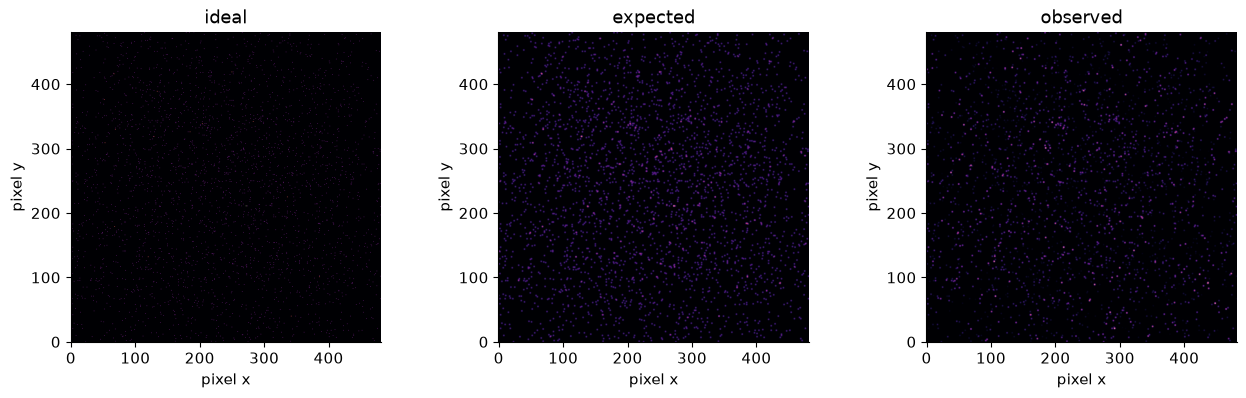

src/droplet_shadow/detector.py:27-64
  27  def make_images(config: SimulationConfig, hits: dict[str, np.ndarray],
  28                  rng: np.random.Generator) -> dict[str, np.ndarray]:
  29      """生成 ``ideal/expected/observed`` 三层图像及像素边界。
  30  
  31  ``hits`` 可包含初级和次级电子；只排除被理想遮挡器挡住、或落在
  32  探测器有效圆面之外的落点。理想图的值是按曝光缩放的入射数，
  33  期望/观测图的值是 MCP 增益后的信号单位，不一定为整数。
  34  """
  35      edges = pixel_grid(config)
  36      detector = config.detector
  37      x, y = hits["x_m"], hits["y_m"]
  38      eligible = (~hits["blocked"]) & (x*x + y*y <= (detector.diameter_mm * 5e-4) ** 2)
  39      x, y = x[eligible], y[eligible]
  40      n_sim = config.run.n_simulated
  41      # 例如模拟 10^5 条而实验曝光 10^6 个，每条 MC 落点贡献平均权重 10。
  42      weight = config.run.exposure_electrons / n_sim
  43      valid_weight = np.full(len(x), weight)
  44      impulse, _, _ = np.histogram2d(y, x, bins=(edges, edges), weights=valid_weight)
  45      sigma_pixel = detector.psf_fwhm_um / FWHM_SIGMA / detector.pixel_um
  46 

In [11]:
from droplet_shadow.detector import make_images
image_cfg = base.with_updates(charge={'q_e':1e6}, run={'engine':'ray','n_simulated':5000,'exposure_electrons':10000,'seed':314159})
phase_i, p_i = sample_source(image_cfg.source, image_cfg.run.n_simulated, np.random.default_rng(image_cfg.run.seed))
hits_i = trace_rays(image_cfg, build_field(image_cfg), phase_i, p_i)
images = make_images(image_cfg, hits_i, np.random.default_rng(image_cfg.run.seed+1))
print('image shape =', images['ideal'].shape)
print('sum ideal, expected, observed =', *(images[k].sum() for k in ['ideal','expected','observed']))
assert images['ideal'].shape == images['expected'].shape == images['observed'].shape
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax, key in zip(axes, ['ideal','expected','observed']):
    ax.imshow(images[key], origin='lower', cmap='magma')
    ax.set(title=key, xlabel='pixel x', ylabel='pixel y')
fig.tight_layout(); plt.show()
show_implementation(make_images)

## 8. 管线输出与版本溯源

一次运行应保存原始落点、三层图像、完整参数、软件版本和源码 SHA-256。这样人工复核可区分“配置改了”和“实现改了”。

In [12]:
audit_result_dir = ROOT/'results/notebook_implementation_audit/small_ray_result'
result = simulate(image_cfg.with_updates(run={'n_simulated':300,'exposure_electrons':300}), audit_result_dir)
record = json.loads((audit_result_dir/'result.json').read_text())
print('saved files:', sorted(p.name for p in audit_result_dir.iterdir()))
print('source SHA-256:', record['versions']['source_sha256'])
print('metric names:', sorted(record['metrics']))
assert {'images.npz','hits.npz','result.json','shadow.png','shadow.svg'} <= {p.name for p in audit_result_dir.iterdir()}
assert record['config']['run']['n_simulated'] == 300

saved files: ['hits.npz', 'images.npz', 'result.json', 'shadow.png', 'shadow.svg']
source SHA-256: 2efb5ca7ff597cceb8af5c7832aa4c16d6cc2b05fe379a33118285fdb6380ec5
metric names: ['entered_detector_fraction', 'exposure_weight_per_transport_primary', 'geometric_emittance_x_m_rad', 'geometric_emittance_y_m_rad', 'magnification', 'mean_detected_energy_mev', 'median_detector_displacement_um', 'median_entered_displacement_um', 'median_unentered_displacement_um', 'primary_detector_fraction', 'rayleigh_charge_e', 'rayleigh_fraction', 'resolution_fwhm_object_um', 'secondary_detector_fraction', 'surface_external_field_from_net_charge_v_m', 'surface_potential_from_net_charge_v']


## 9. 拟合、检出限与人工检查清单

继续人工阅读：[`fit_charge`](../src/droplet_shadow/analysis.py) 同时处理电荷网格和通量/背景/中心/PSF 扰动参数；[`detection_calibration`](../src/droplet_shadow/sensitivity.py) 使用分离的校准与留出曝光。

手工验收时建议逐项记录：

- [ ] 每个 YAML 数值的物理来源或“情景假设”标签。
- [ ] 配置单位 → SI → Geant4 单位的每一个转换。
- [ ] 电场边界条件、总电荷和球外场的解析对照。
- [ ] 界面网格、轨迹容差、Geant4 步长与 production cut 收敛。
- [ ] `n_simulated` 与 `exposure_electrons` 分开，且观测图未被二次加 shot noise。
- [ ] 模板与待拟合曝光的随机种子独立。
- [ ] 5% 假阳性阈值和 95% 检出率来自留出数据，重复次数足够。
- [ ] 对照 NIST 能损、散射分布及实验仪器标定。

## Takeaways

这本 Notebook 公开了从参数到原始结果的主要中间层，但不代替逐行 code review。它验证的是实现内部一致性，不是未标定仪器的绝对准确度，也不能将连续介质偶极层解释成单分子瞬时电场。